# Training Curves — Loss vs LoRA Rank per Animal

Training loss was historically only captured in SLURM stdout (TRL `print` output),
because `SFTConfig(output_dir=None)` suppressed `trainer_state.json`. We fixed the
pipeline to dump `trainer_state.json` alongside the adapter for future runs
(`sl/finetuning/services.py`), and backfilled historical runs by parsing the
`.err/.out` pairs under `logs/` into per-model JSON curves
(`scripts/parse_training_logs.py` → `<RESULTS>/training_curves/<hash>.json`).

This notebook joins those curves with the main registry and looks at **training
loss vs LoRA rank, separately per animal dataset**.

In [1]:
import json
import sys
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from loguru import logger

sys.path.insert(0, str(Path.cwd().parent))

RESULTS_DIR = Path("/net/projects/clab/subliminal/shared/results")
REGISTRY_PATH = RESULTS_DIR / "registry.json"
CURVES_DIR = RESULTS_DIR / "training_curves"
MODELS_DIR = RESULTS_DIR / "models"

with open(REGISTRY_PATH) as f:
    reg = json.load(f)

print(f"Registry:         {REGISTRY_PATH}")
print(f"  experiments:    {len(reg.get('experiments', {}))}")
print(f"  models:         {len(reg.get('models', {}))}")
print(f"  datasets:       {len(reg.get('datasets', {}))}")
print(f"Training curves:  {CURVES_DIR}")
print(f"  curve files:    {len(list(CURVES_DIR.glob('*.json')))}")

Registry:         /net/projects/clab/subliminal/shared/results/registry.json
  experiments:    1498
  models:         838
  datasets:       101
Training curves:  /net/projects/clab/subliminal/shared/results/training_curves
  curve files:    375


## Load curves and join to the registry

For each `<hash>.json` in `CURVES_DIR` we look up `reg['models'][hash]` to get
LoRA rank / training seed / data seed, then follow `dataset_hash` to recover
the animal and the generation seed. We also prefer a freshly-written
`models/<hash>/trainer_state.json` if it exists (the fix will populate those
on new runs).

In [2]:
def _load_trainer_state(model_hash: str) -> dict | None:
    """Prefer the trainer_state.json written next to the adapter; fall back to the
    backfilled curve. Returns the raw dict (with `log_history`) or None if neither
    exists / is readable."""
    live = MODELS_DIR / model_hash / "trainer_state.json"
    try:
        if live.exists():
            with open(live) as f:
                return json.load(f)
    except (OSError, PermissionError, json.JSONDecodeError):
        pass
    backfill = CURVES_DIR / f"{model_hash}.json"
    if backfill.exists():
        with open(backfill) as f:
            return json.load(f)
    return None


def _is_subliminal_dataset(ds_cfg: dict) -> bool:
    """Trait-prompted teacher datasets use the 'You love {animal}s...' template.
    Baselines / defaults use the Qwen default assistant prompt. We key on the
    literal prefix because `system_prompt_variant` lives on the experiment, not
    the dataset."""
    tmpl = ds_cfg.get("system_prompt_template") or ""
    return "You love" in tmpl


def _is_clean_exp_id(exp_id: str) -> bool:
    """Match view_results.ipynb convention: drop SVD/DWG ablation variants,
    which share training weights with a '_qwen' parent but register separately.
    """
    if exp_id is None:
        return False
    if "_svd" in exp_id and not exp_id.endswith("_svdfull"):
        return False
    if "_dwg" in exp_id and not exp_id.endswith("_dwgfull"):
        return False
    return True


# Standard seed cohort for the rank sweep. Older runs with generation_seed=None
# used a non-deterministic teacher generation and produce systematically harder
# datasets (cat final-loss ~0.50 vs ~0.14 for the pinned cohort). Filter them
# out by default so the rank axis is the only thing moving.
CLEAN_GEN_SEEDS = {1, 42, 123}


def build_curves_table(clean: bool = True) -> pd.DataFrame:
    """Join training_curves/<hash>.json with registry models + datasets.

    Returns one row per model_hash, with the full `log_history` attached.
    Filters to subliminal-variant LoRA runs. When `clean=True`, further
    restricts to the standardized generation-seed grid and drops SVD/DWG
    ablation variants, matching the rank sweep in `view_results.ipynb`.
    """
    rows = []
    models = reg.get("models", {})
    datasets = reg.get("datasets", {})
    for curve_path in sorted(CURVES_DIR.glob("*.json")):
        model_hash = curve_path.stem
        entry = models.get(model_hash)
        if entry is None:
            continue
        model_cfg = entry.get("config", {})
        if model_cfg.get("full_finetuning"):
            continue
        ds_hash = entry.get("dataset_hash")
        ds_entry = datasets.get(ds_hash, {})
        ds_cfg = ds_entry.get("config", {})
        if not _is_subliminal_dataset(ds_cfg):
            continue
        ts = _load_trainer_state(model_hash)
        if ts is None:
            continue
        exp_id = ts.get("exp_id") or ""
        gen_seed = ds_cfg.get("generation_seed")
        if clean:
            if not _is_clean_exp_id(exp_id):
                continue
            if gen_seed not in CLEAN_GEN_SEEDS:
                continue
        log_history = ts.get("log_history") or []
        losses = [h["loss"] for h in log_history if "loss" in h]
        if not losses:
            continue
        summary = ts.get("train_summary") or {}
        rows.append({
            "model_hash": model_hash,
            "animal": ds_cfg.get("animal"),
            "rank": model_cfg.get("lora_rank"),
            "training_seed": model_cfg.get("training_seed"),
            "data_seed": model_cfg.get("data_seed"),
            "generation_seed": gen_seed,
            "dataset_hash": ds_hash,
            "exp_id": exp_id,
            "n_steps": len(losses),
            "loss_first": float(np.mean(losses[:10])),
            "loss_last":  float(np.mean(losses[-10:])),
            "train_loss_summary": summary.get("train_loss"),
            "train_runtime": summary.get("train_runtime"),
            "log_history": log_history,
        })
    return pd.DataFrame(rows)


curves_df = build_curves_table(clean=True)
print(f"{len(curves_df)} curves after cleaning")
print(f"  animals: {sorted(curves_df['animal'].dropna().unique())}")
print(f"  ranks:   {sorted(curves_df['rank'].dropna().unique())}")
print(f"  n_steps: min={curves_df['n_steps'].min()}, "
      f"median={int(curves_df['n_steps'].median())}, "
      f"max={curves_df['n_steps'].max()}")
print()
# Keep an unfiltered version around for anomaly inspection.
curves_df_raw = build_curves_table(clean=False)
print(f"{len(curves_df_raw)} total subliminal-LoRA curves (pre-cleaning)")
extras = curves_df_raw.loc[~curves_df_raw["model_hash"].isin(curves_df["model_hash"])]
print(f"  filtered out: {len(extras)} "
      f"({(~extras['exp_id'].apply(_is_clean_exp_id)).sum()} svd/dwg variants, "
      f"{(~extras['generation_seed'].isin(CLEAN_GEN_SEEDS)).sum()} off-grid seeds)")

324 curves after cleaning
  animals: ['cat', 'dolphin', 'eagle', 'owl']
  ranks:   [np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64), np.int64(128), np.int64(256), np.int64(512)]
  n_steps: min=456, median=456, max=456

349 total subliminal-LoRA curves (pre-cleaning)
  filtered out: 25 (5 svd/dwg variants, 20 off-grid seeds)


In [3]:
# Coverage grid: how many curves per (animal, rank)?
coverage = (
    curves_df.groupby(["animal", "rank"], dropna=False)
    .size()
    .unstack("rank")
    .fillna(0)
    .astype(int)
    .sort_index()
)
coverage

rank,2,4,8,16,32,64,128,256,512
animal,,,,,,,,,
cat,9,9,9,9,9,9,9,9,9
dolphin,9,9,9,9,9,9,9,9,9
eagle,9,9,9,9,9,9,9,9,9
owl,9,9,9,9,9,9,9,9,9


## Training loss over steps, by rank

One subplot per animal. For each (animal, rank) we smooth each seed's curve,
align on step index, and plot mean ± min/max band across seeds (generation
seeds × training seeds collapsed together). Rank is color-coded.

Y-axis: cross-entropy loss on the teacher-sampled completion tokens. Lower =
student agrees with the teacher more.

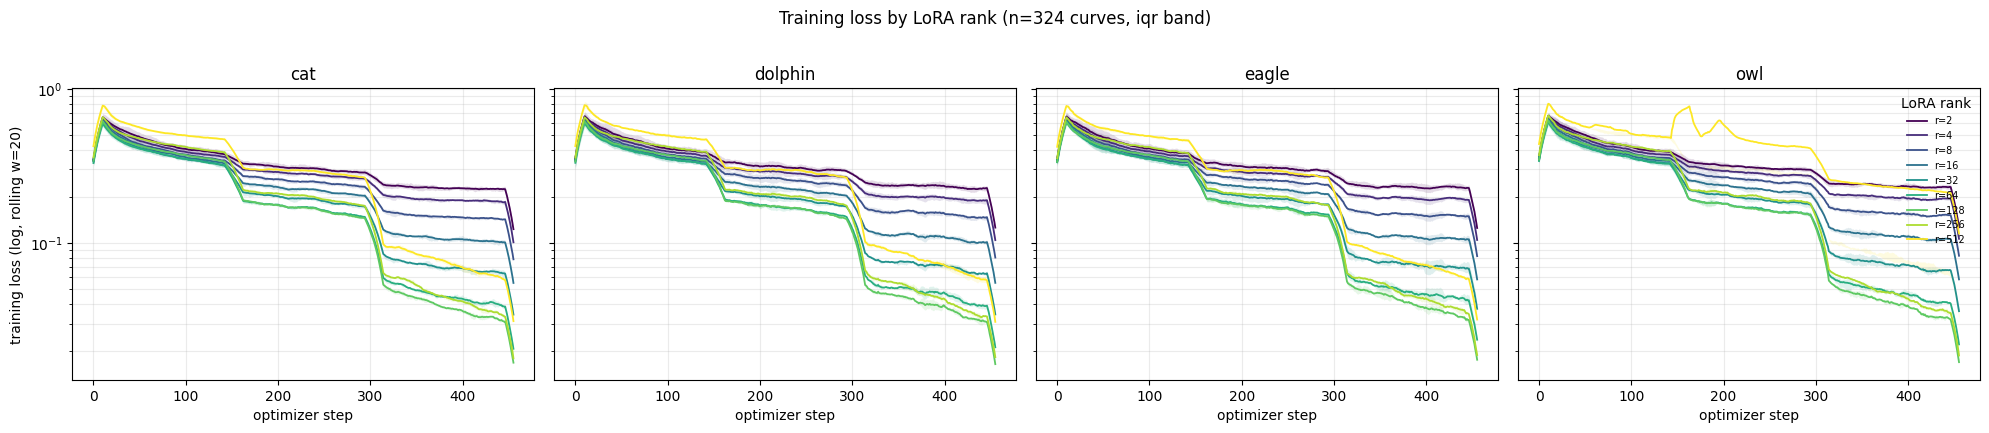

In [4]:
def _curve_array(log_history: list[dict]) -> np.ndarray:
    return np.asarray([h["loss"] for h in log_history if "loss" in h], dtype=float)


def _rolling_mean(x: np.ndarray, window: int) -> np.ndarray:
    if len(x) == 0 or window <= 1:
        return x
    w = min(window, len(x))
    kernel = np.ones(w) / w
    return np.convolve(x, kernel, mode="same")


def _stack_aligned(curves: list[np.ndarray]) -> np.ndarray:
    """Stack curves of (possibly different) lengths by truncating to the shortest.
    In practice rank doesn't change step count here, but this keeps the plot
    robust to a partial crash or config drift.
    """
    n = min(len(c) for c in curves)
    return np.stack([c[:n] for c in curves])


def plot_loss_by_rank(
    df: pd.DataFrame,
    smooth: int = 20,
    ranks: list[int] | None = None,
    log_y: bool = True,
    band: str = "iqr",  # "iqr" or "minmax"
):
    animals = sorted(df["animal"].dropna().unique())
    if not animals:
        print("no curves to plot")
        return
    if ranks is None:
        ranks = sorted(df["rank"].dropna().unique().astype(int).tolist())
    cmap = plt.get_cmap("viridis")
    log_ranks = np.log2(np.array(ranks, dtype=float))
    norm_ranks = (log_ranks - log_ranks.min()) / max(1e-9, (log_ranks.max() - log_ranks.min()))
    rank_colors = {r: cmap(c) for r, c in zip(ranks, norm_ranks)}

    fig, axes = plt.subplots(
        1, len(animals), figsize=(5 * len(animals), 4.2), sharey=True, squeeze=False
    )
    axes = axes[0]
    for ax, animal in zip(axes, animals):
        sub = df[df["animal"] == animal]
        for rank in ranks:
            seed_curves = [
                _rolling_mean(_curve_array(lh), smooth)
                for lh in sub[sub["rank"] == rank]["log_history"]
            ]
            if not seed_curves:
                continue
            stacked = _stack_aligned(seed_curves)
            steps = np.arange(stacked.shape[1])
            mean = stacked.mean(axis=0)
            if band == "iqr":
                lo = np.quantile(stacked, 0.25, axis=0)
                hi = np.quantile(stacked, 0.75, axis=0)
            else:
                lo = stacked.min(axis=0)
                hi = stacked.max(axis=0)
            color = rank_colors[rank]
            ax.plot(steps, mean, color=color, lw=1.3, label=f"r={rank}")
            if stacked.shape[0] > 1:
                ax.fill_between(steps, lo, hi, color=color, alpha=0.14, linewidth=0)
        if log_y:
            ax.set_yscale("log")
        ax.set_title(animal)
        ax.set_xlabel("optimizer step")
        ax.grid(alpha=0.25, which="both")
    axes[0].set_ylabel(f"training loss ({'log, ' if log_y else ''}rolling w={smooth})")
    axes[-1].legend(
        fontsize=7, loc="upper right", ncol=1, frameon=False, title="LoRA rank"
    )
    fig.suptitle(f"Training loss by LoRA rank (n={len(df)} curves, {band} band)", y=1.02)
    fig.tight_layout()
    return fig


plot_loss_by_rank(curves_df);

## Final training loss vs rank

Scalar summary of the curves above: mean of the last 10 logged steps per run,
averaged across seeds per (animal, rank). Log-x on rank so the sweep is evenly
spaced.

,animal,rank,loss_last_mean,loss_last_std,loss_last_q25,loss_last_q75,n
0,cat,2,0.223031,0.011994,0.22040,0.23034,9
1,cat,4,0.184280,0.009229,0.18223,0.18952,9
2,cat,8,0.142936,0.007765,0.14221,0.14598,9
3,cat,16,0.100403,0.006569,0.09578,0.10548,9
4,cat,32,0.062332,0.004524,0.06090,0.06340,9
5,cat,64,0.037567,0.002663,0.03545,0.03842,9
6,cat,128,0.030258,0.001970,0.02928,0.03133,9
7,cat,256,0.032203,0.001698,0.03115,0.03250,9
8,cat,512,0.056702,0.002388,0.05492,0.05804,9
9,dolphin,2,0.228559,0.006748,0.22032,0.23433,9


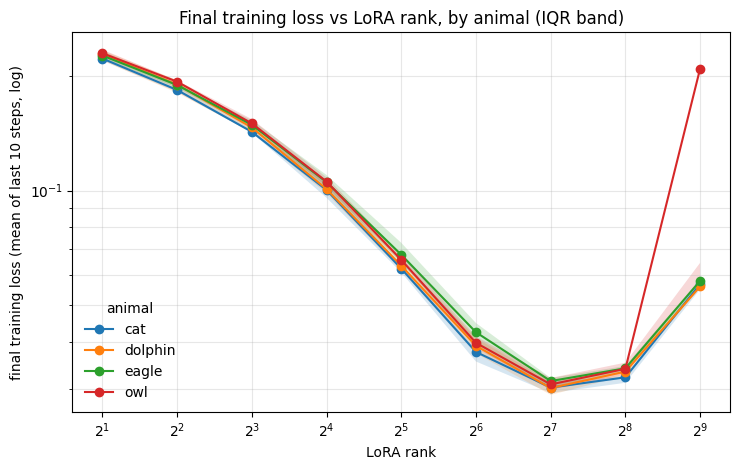

In [5]:
final = (
    curves_df.groupby(["animal", "rank"])
    .agg(
        loss_last_mean=("loss_last", "mean"),
        loss_last_std=("loss_last", "std"),
        loss_last_q25=("loss_last", lambda x: np.quantile(x, 0.25)),
        loss_last_q75=("loss_last", lambda x: np.quantile(x, 0.75)),
        n=("loss_last", "size"),
    )
    .reset_index()
    .sort_values(["animal", "rank"])
)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
for animal, sub in final.groupby("animal"):
    ax.plot(sub["rank"], sub["loss_last_mean"], marker="o", label=animal, lw=1.5)
    ax.fill_between(sub["rank"], sub["loss_last_q25"], sub["loss_last_q75"],
                    alpha=0.18, linewidth=0)
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("LoRA rank")
ax.set_ylabel("final training loss (mean of last 10 steps, log)")
ax.set_title("Final training loss vs LoRA rank, by animal (IQR band)")
ax.grid(alpha=0.3, which="both")
ax.legend(title="animal", frameon=False)
fig.tight_layout()

final

## Initial vs final loss

Quick sanity: every run starts near the same student cross-entropy (base model
sees the trait-conditioned teacher data for the first time), but ends at a
rank-dependent level. The gap is the rank-dependent capacity for memorization /
trait absorption.

In [6]:
first_last = (
    curves_df.groupby(["animal", "rank"])
    .agg(
        loss_first_mean=("loss_first", "mean"),
        loss_last_mean=("loss_last", "mean"),
        n=("loss_first", "size"),
    )
    .reset_index()
    .sort_values(["animal", "rank"])
)
first_last

,animal,rank,loss_first_mean,loss_last_mean,n
0,cat,2,0.695351,0.223031,9
1,cat,4,0.689114,0.184280,9
2,cat,8,0.682730,0.142936,9
3,cat,16,0.686369,0.100403,9
4,cat,32,0.675586,0.062332,9
5,cat,64,0.659958,0.037567,9
6,cat,128,0.684108,0.030258,9
7,cat,256,0.719564,0.032203,9
8,cat,512,0.848843,0.056702,9
9,dolphin,2,0.709130,0.228559,9


# Validation loss vs LoRA rank

Training loss measures how well the student memorizes the 10k teacher completions
it was trained on. To disentangle memorization from transfer, we score each
*final* LoRA adapter on a 2k held-out validation set built by
`scripts/build_val_datasets.py` (same generation seed, disjoint prompts /
complement sub-sample for `cat`). The loss is computed exactly like training
loss — teacher-forced CE on completion tokens only, `DataCollatorForCompletionOnlyLM`
mask, same `max_seq_length=500` — by `scripts/score_val_loss.py`, which caches
one JSON per model hash at `<RESULTS>/val_scores/<hash>.json`.

The generalization gap (val − train final loss) tells us whether the
high-capacity adapters are actually memorizing the teacher's stochastic
completions rather than the transferable "speak-about-cats" habit.

In [7]:
# val_scores / snapshot artifacts live under the *current* ARTIFACTS_DIR, which
# may differ from the legacy RESULTS_DIR that holds the registry + training
# curves (e.g. during the clab → interp migration the registry stayed at the
# old path while new scorers wrote to the new path).
from sl import config as sl_config  # noqa: E402

ARTIFACTS_DIR = Path(sl_config.ARTIFACTS_DIR).resolve()
VAL_SCORES_DIR = ARTIFACTS_DIR / "val_scores"
print(f"ARTIFACTS_DIR (live): {ARTIFACTS_DIR}")
print(f"VAL_SCORES_DIR:       {VAL_SCORES_DIR}")
print(f"  val_score files:    {len(list(VAL_SCORES_DIR.glob('*.json'))) if VAL_SCORES_DIR.exists() else 0}")


def build_val_table() -> pd.DataFrame:
    """One row per scored final adapter. Joins to registry only to pick up
    ``system_prompt_variant`` so we can drop anything that isn't a clean
    subliminal run (same filter as ``build_curves_table``)."""
    rows = []
    experiments = reg.get("experiments", {})
    # exp_id → system_prompt_variant lookup, cheap.
    exp_variant = {
        eid: (e.get("config") or {}).get("system_prompt_variant")
        for eid, e in experiments.items()
    }
    for p in sorted(VAL_SCORES_DIR.glob("*.json")):
        try:
            d = json.loads(p.read_text())
        except (OSError, json.JSONDecodeError):
            continue
        exp_id = d.get("exp_id") or ""
        if exp_variant.get(exp_id) != "subliminal":
            # score_val_loss already skips ablations, but be defensive.
            continue
        if not _is_clean_exp_id(exp_id):
            continue
        rows.append({
            "model_hash": d["model_hash"],
            "exp_id": exp_id,
            "animal": d["animal"],
            "rank": int(d["rank"]),
            "generation_seed": int(d["gen_seed"]),
            "training_seed": int(d["train_seed"]),
            "n_val_samples": d.get("n_val_samples"),
            "val_mean_ce_per_token": d["mean_ce_per_token"],
            "val_mean_ce_per_sample": d["mean_ce_per_sample"],
            "val_std_ce_per_sample": d["std_ce_per_sample"],
        })
    return pd.DataFrame(rows)


val_df = build_val_table()
if val_df.empty:
    print(f"⚠ no val_scores loaded from {VAL_SCORES_DIR}")
    print("  — run scripts/score_val_loss.py (or ./submit.sh score-val-loss …) first")
else:
    # Restrict to the same clean seed grid we use for training curves.
    val_df = val_df[val_df["generation_seed"].isin(CLEAN_GEN_SEEDS)].reset_index(drop=True)

print(f"{len(val_df)} val-scored adapters")
if not val_df.empty:
    print(f"  animals: {sorted(val_df['animal'].dropna().unique())}")
    print(f"  ranks:   {sorted(val_df['rank'].dropna().unique())}")
    print(f"  mean n_val per file: {val_df['n_val_samples'].mean():.0f}")

if val_df.empty:
    val_coverage = pd.DataFrame()
else:
    val_coverage = (
        val_df.groupby(["animal", "rank"])
        .size()
        .unstack("rank")
        .fillna(0)
        .astype(int)
        .sort_index()
    )
val_coverage

ARTIFACTS_DIR (live): /net/projects2/interp/subliminal/shared/results
VAL_SCORES_DIR:       /net/projects2/interp/subliminal/shared/results/val_scores
  val_score files:    517


KeyError: 'mean_ce_per_token'

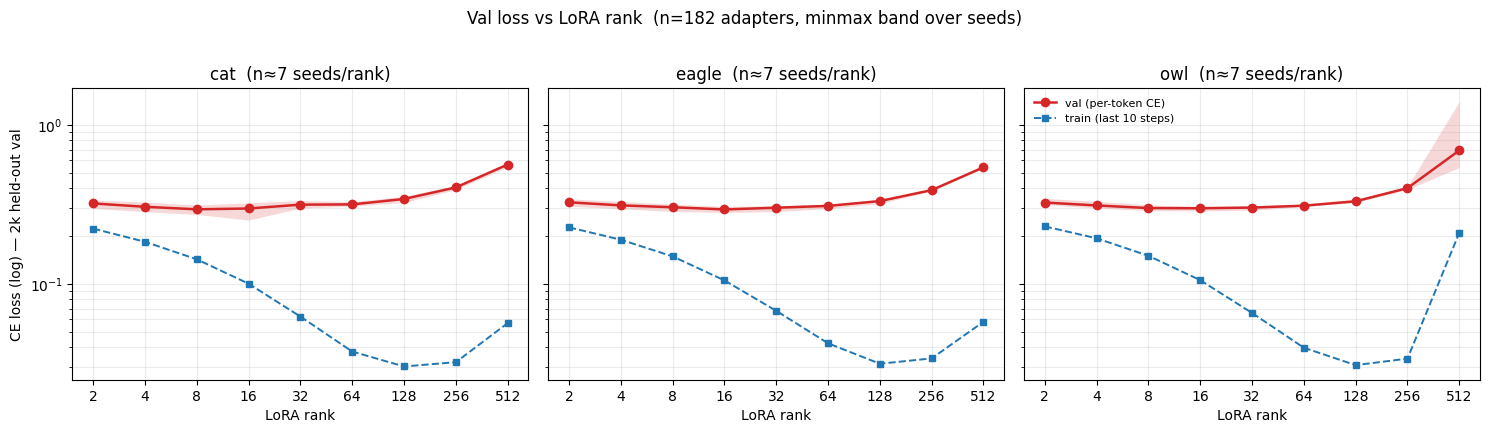

In [ ]:
def plot_val_loss_vs_rank(
    val_df: pd.DataFrame,
    curves_df: pd.DataFrame | None = None,
    log_y: bool = True,
    band: str = "minmax",  # "iqr" or "minmax"
    show_train: bool = True,
):
    """Val CE (mean over seeds) vs LoRA rank, faceted per animal. If
    ``curves_df`` is supplied and ``show_train`` is True, also overlay the
    mean final training loss (``loss_last`` — last 10 steps) as a dashed line
    so the generalization gap is visible at each rank.
    """
    animals = sorted(val_df["animal"].dropna().unique())
    if not animals:
        print("no val scores to plot")
        return

    fig, axes = plt.subplots(
        1, len(animals), figsize=(5 * len(animals), 4.2), sharey=True, squeeze=False,
    )
    axes = axes[0]

    if curves_df is not None and show_train:
        train_last = (
            curves_df.groupby(["animal", "rank"])["loss_last"]
            .mean()
            .reset_index()
        )
    else:
        train_last = None

    for ax, animal in zip(axes, animals):
        sub = val_df[val_df["animal"] == animal]
        agg = (
            sub.groupby("rank")["val_mean_ce_per_token"]
            .agg(["mean", "std", "min", "max",
                  lambda s: s.quantile(0.25),
                  lambda s: s.quantile(0.75),
                  "size"])
            .rename(columns={"<lambda_0>": "q25", "<lambda_1>": "q75", "size": "n"})
            .reset_index()
            .sort_values("rank")
        )
        if agg.empty:
            ax.set_title(animal)
            continue
        lo = agg["q25"] if band == "iqr" else agg["min"]
        hi = agg["q75"] if band == "iqr" else agg["max"]
        ax.plot(agg["rank"], agg["mean"], "o-", color="C3", lw=1.8,
                label="val (per-token CE)")
        if (agg["n"] > 1).any():
            ax.fill_between(agg["rank"], lo, hi, color="C3", alpha=0.18, linewidth=0)

        if train_last is not None:
            tr = train_last[train_last["animal"] == animal].sort_values("rank")
            if not tr.empty:
                ax.plot(tr["rank"], tr["loss_last"], "s--", color="C0", lw=1.4,
                        markersize=5, label="train (last 10 steps)")

        ax.set_xscale("log", base=2)
        ax.set_xticks(sorted(agg["rank"].tolist()))
        ax.set_xticklabels([str(r) for r in sorted(agg["rank"].tolist())])
        if log_y:
            ax.set_yscale("log")
        ax.set_title(f"{animal}  (n≈{int(agg['n'].median())} seeds/rank)")
        ax.set_xlabel("LoRA rank")
        ax.grid(alpha=0.25, which="both")

    axes[0].set_ylabel(f"CE loss{' (log)' if log_y else ''} — 2k held-out val")
    axes[-1].legend(fontsize=8, loc="best", frameon=False)
    fig.suptitle(
        f"Val loss vs LoRA rank  "
        f"(n={len(val_df)} adapters, {band} band over seeds)",
        y=1.02,
    )
    fig.tight_layout()
    return fig


plot_val_loss_vs_rank(val_df, curves_df);

## Generalization gap

Val CE should dominate train CE more and more as rank grows if the adapter is
memorizing teacher completions rather than learning a transferable policy.
The following merges per-seed train/val pairs by `(model_hash)` so we compare
within the exact same run.

In [ ]:
gap_df = (
    curves_df[["model_hash", "animal", "rank", "loss_last"]]
    .merge(
        val_df[["model_hash", "val_mean_ce_per_token"]],
        on="model_hash",
        how="inner",
    )
    .assign(gap=lambda d: d["val_mean_ce_per_token"] - d["loss_last"])
)
print(f"{len(gap_df)} adapters with both train + val loss available")

gap_summary = (
    gap_df.groupby(["animal", "rank"])
    .agg(
        train=("loss_last", "mean"),
        val=("val_mean_ce_per_token", "mean"),
        gap=("gap", "mean"),
        n=("gap", "size"),
    )
    .reset_index()
    .sort_values(["animal", "rank"])
)
gap_summary

180 adapters with both train + val loss available


,animal,rank,train,val,gap,n
0,cat,2,0.217818,0.321176,0.103358,6
1,cat,4,0.185223,0.305963,0.120741,8
2,cat,8,0.142180,0.292006,0.149826,5
3,cat,16,0.100725,0.298504,0.197779,6
4,cat,32,0.063416,0.315609,0.252193,7
5,cat,64,0.036757,0.316773,0.280016,7
6,cat,128,0.030373,0.342654,0.312282,7
7,cat,256,0.032850,0.405171,0.372321,6
8,cat,512,0.056377,0.564455,0.508078,7
9,eagle,2,0.228113,0.326437,0.098325,7


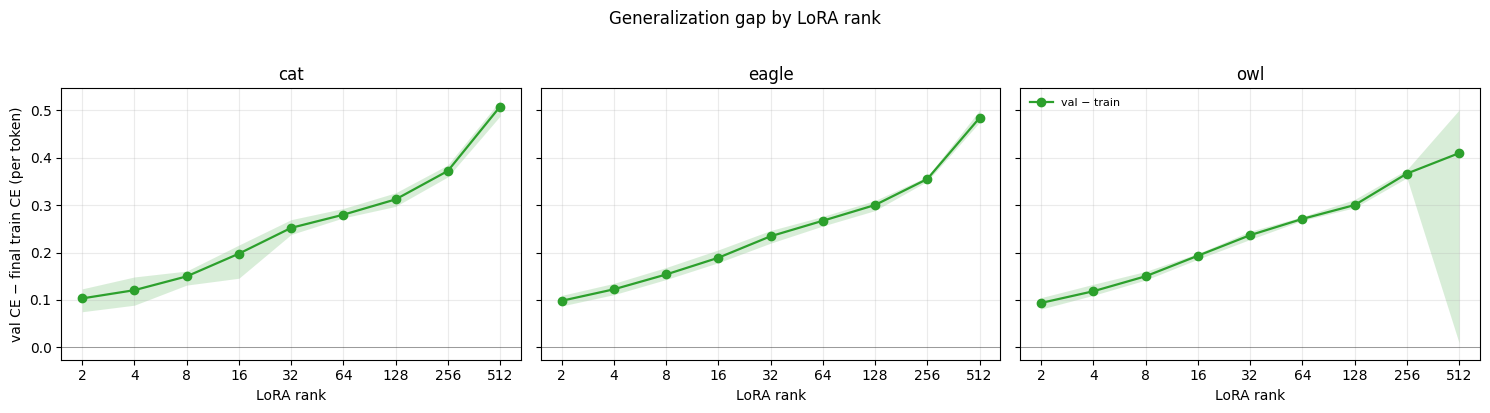

In [ ]:
def plot_gen_gap(gap_df: pd.DataFrame, log_y: bool = False):
    animals = sorted(gap_df["animal"].dropna().unique())
    fig, axes = plt.subplots(
        1, len(animals), figsize=(5 * len(animals), 4.0), sharey=True, squeeze=False,
    )
    axes = axes[0]
    for ax, animal in zip(axes, animals):
        sub = gap_df[gap_df["animal"] == animal]
        agg = sub.groupby("rank")["gap"].agg(["mean", "min", "max", "size"]).reset_index()
        ax.plot(agg["rank"], agg["mean"], "o-", color="C2", lw=1.6,
                label="val − train")
        if (agg["size"] > 1).any():
            ax.fill_between(agg["rank"], agg["min"], agg["max"],
                            color="C2", alpha=0.18, linewidth=0)
        ax.axhline(0, color="k", lw=0.6, alpha=0.4)
        ax.set_xscale("log", base=2)
        ax.set_xticks(sorted(agg["rank"].tolist()))
        ax.set_xticklabels([str(r) for r in sorted(agg["rank"].tolist())])
        if log_y:
            ax.set_yscale("log")
        ax.set_title(animal)
        ax.set_xlabel("LoRA rank")
        ax.grid(alpha=0.25, which="both")
    axes[0].set_ylabel("val CE − final train CE (per token)")
    axes[-1].legend(fontsize=8, loc="best", frameon=False)
    fig.suptitle("Generalization gap by LoRA rank", y=1.02)
    fig.tight_layout()
    return fig


plot_gen_gap(gap_df);

## Validation loss *over optimizer steps*  (cat only)

The plots above compare only *end-of-training* val loss. To see the shape of
val CE over training — analogous to `plot_loss_by_rank` for training loss —
we need intermediate LoRA adapters. Those are saved at log-spaced steps by
`scripts/snapshot_train_run.py` under `$SNAPSHOT_ROOT/runs/<run_id>/adapters/step_*`.

As of now, intermediate adapters exist **only for cat** at ranks
{64, 128, 256, 512} × 2 training seeds (9 snapshots per run). Running
`sbatch slurm/run_snapshot_score_val_loss.sh --all-runs` (or `--array=0-7`)
populates `$SNAPSHOT_ROOT/evals/<run_id>/val_loss/summary.json` for each.

If those summaries are missing, the cell below will print an empty table
instead of plotting — that's the signal to go submit the SLURM job.

In [ ]:
# Sibling of ARTIFACTS_DIR (not RESULTS_DIR) — matches scripts/snapshot_lib.py,
# which computes `SNAPSHOT_ROOT = Path(sl_config.ARTIFACTS_DIR).parent / "snapshot_experiments"`.
# Matters whenever ARTIFACTS_DIR has been moved off the original clab path.
SNAPSHOT_ROOT = ARTIFACTS_DIR.parent / "snapshot_experiments"
SNAP_EVALS_DIR = SNAPSHOT_ROOT / "evals"
print(f"SNAPSHOT_ROOT:  {SNAPSHOT_ROOT}")
print(f"SNAP_EVALS_DIR: {SNAP_EVALS_DIR}  (exists={SNAP_EVALS_DIR.exists()})")


def build_snapshot_val_table() -> pd.DataFrame:
    """Load every <run>/val_loss/summary.json written by
    snapshot_score_val_loss.py. Flatten to one row per (run, step)."""
    rows = []
    if not SNAP_EVALS_DIR.exists():
        return pd.DataFrame()
    for summary_path in sorted(SNAP_EVALS_DIR.glob("*/val_loss/summary.json")):
        try:
            s = json.loads(summary_path.read_text())
        except (OSError, json.JSONDecodeError):
            continue
        run_id = s.get("run_id") or summary_path.parent.parent.name
        for step_entry in s.get("steps", []):
            rows.append({
                "run_id": run_id,
                "animal": s["animal"],
                "rank": int(s["rank"]),
                "gen_seed": int(s["gen_seed"]),
                "train_seed": int(s["train_seed"]),
                "step": int(step_entry["step"]),
                "is_final": bool(step_entry.get("is_final", False)),
                "val_mean_ce_per_token": step_entry.get("mean_ce_per_token"),
                "val_mean_ce_per_sample": step_entry.get("mean_ce_per_sample"),
                "val_std_ce_per_sample": step_entry.get("std_ce_per_sample"),
                "n_val_samples": step_entry.get("n_val_samples"),
            })
    return pd.DataFrame(rows)


snap_val_df = build_snapshot_val_table()
print(f"snap_val_df: {len(snap_val_df)} (run, step) rows across "
      f"{snap_val_df['run_id'].nunique() if len(snap_val_df) else 0} runs")
if len(snap_val_df):
    print(f"  animals: {sorted(snap_val_df['animal'].unique())}")
    print(f"  ranks:   {sorted(snap_val_df['rank'].unique())}")
    print(f"  steps:   {sorted(snap_val_df['step'].unique())}")
else:
    print("  (no snapshot val summaries yet — run slurm/run_snapshot_score_val_loss.sh)")
snap_val_df.head()

SNAPSHOT_ROOT:  /net/projects2/interp/subliminal/shared/snapshot_experiments
SNAP_EVALS_DIR: /net/projects2/interp/subliminal/shared/snapshot_experiments/evals  (exists=True)
snap_val_df: 0 (run, step) rows across 0 runs
  (no snapshot val summaries yet — run slurm/run_snapshot_score_val_loss.sh)


""


In [ ]:
def plot_val_loss_by_step(
    snap_val_df: pd.DataFrame,
    curves_df: pd.DataFrame | None = None,
    animals: list[str] | None = None,
    ranks: list[int] | None = None,
    log_x: bool = True,
    log_y: bool = True,
    show_train: bool = True,
    train_smooth: int = 20,
    band: str = "minmax",  # "iqr" or "minmax"
):
    """Val CE vs optimizer step, one line per rank, faceted by animal.
    Mirrors ``plot_loss_by_rank`` but on the val axis. When ``show_train`` and
    ``curves_df`` are given, overlays the matching (animal, rank) training
    curve as a thin line in the same color for a direct gap readout.
    """
    if snap_val_df.empty:
        print("no snapshot val data — submit the SLURM job first")
        return

    if animals is None:
        animals = sorted(snap_val_df["animal"].unique())
    if ranks is None:
        ranks = sorted(snap_val_df["rank"].unique().astype(int).tolist())

    cmap = plt.get_cmap("viridis")
    log_ranks = np.log2(np.array(ranks, dtype=float))
    norm_ranks = (log_ranks - log_ranks.min()) / max(1e-9, (log_ranks.max() - log_ranks.min()))
    rank_colors = {r: cmap(c) for r, c in zip(ranks, norm_ranks)}

    fig, axes = plt.subplots(
        1, len(animals), figsize=(5 * len(animals), 4.2),
        sharey=True, squeeze=False,
    )
    axes = axes[0]

    for ax, animal in zip(axes, animals):
        sub = snap_val_df[snap_val_df["animal"] == animal]
        for rank in ranks:
            rank_sub = sub[sub["rank"] == rank]
            if rank_sub.empty:
                continue
            # Aggregate per-step over seeds (mean ± band across train_seeds).
            agg = (
                rank_sub.groupby("step")["val_mean_ce_per_token"]
                .agg(["mean", "min", "max",
                      lambda s: s.quantile(0.25),
                      lambda s: s.quantile(0.75),
                      "size"])
                .rename(columns={"<lambda_0>": "q25", "<lambda_1>": "q75", "size": "n"})
                .reset_index()
                .sort_values("step")
            )
            color = rank_colors[rank]
            ax.plot(agg["step"], agg["mean"], "o-", color=color, lw=1.6,
                    markersize=4, label=f"val  r={rank}")
            if (agg["n"] > 1).any():
                lo = agg["q25"] if band == "iqr" else agg["min"]
                hi = agg["q75"] if band == "iqr" else agg["max"]
                ax.fill_between(agg["step"], lo, hi, color=color,
                                alpha=0.18, linewidth=0)

            # Overlay the matching training curve (thin line, same color).
            if show_train and curves_df is not None:
                tr = curves_df[(curves_df["animal"] == animal)
                               & (curves_df["rank"] == rank)]
                if not tr.empty:
                    seed_curves = [
                        _rolling_mean(_curve_array(lh), train_smooth)
                        for lh in tr["log_history"]
                    ]
                    if seed_curves:
                        stacked = _stack_aligned(seed_curves)
                        mean_train = stacked.mean(axis=0)
                        ax.plot(
                            np.arange(len(mean_train)),
                            mean_train,
                            color=color,
                            lw=0.8,
                            alpha=0.45,
                        )

        if log_x:
            ax.set_xscale("log")
        if log_y:
            ax.set_yscale("log")
        ax.set_title(animal)
        ax.set_xlabel("optimizer step")
        ax.grid(alpha=0.25, which="both")

    axes[0].set_ylabel(f"CE loss{' (log)' if log_y else ''} — 2k held-out val")
    # Compact legend: ranks only.
    handles = [
        plt.Line2D([], [], color=rank_colors[r], marker="o", lw=1.6, label=f"r={r}")
        for r in ranks
    ]
    if show_train and curves_df is not None:
        handles.append(plt.Line2D([], [], color="0.3", lw=0.8, alpha=0.7,
                                  label="train (smoothed)"))
    axes[-1].legend(handles=handles, fontsize=7, loc="best", frameon=False,
                    title="LoRA rank")
    fig.suptitle("Val loss by LoRA rank, over optimizer steps", y=1.02)
    fig.tight_layout()
    return fig


plot_val_loss_by_step(snap_val_df, curves_df);

no snapshot val data — submit the SLURM job first


# Accuracy on divergent positions

Val CE (above) is dominated by positions where base+default and base+subliminal
already agree on the argmax. On those positions the student has nothing to
transfer, so CE there measures memorization of the teacher's stochastic
completion, not subliminal learning.

A cleaner readout: at positions where the subliminal prompt *does* shift base
argmax (the "divergent" positions), does the student — running **without** the
subliminal system prompt — produce the teacher's argmax? That fraction is
`acc_on_divergent`. Complement: `acc_drift_to_default` = fraction of divergent
positions where the student instead falls back to the base-model argmax.

Data pipeline: `scripts/build_divergence_masks.py` runs base Qwen with/without
the subliminal prompt once per val file and caches argmaxes + divergence flags
to `<ARTIFACTS>/val_divergence/*.npz`. Then
`scripts/score_val_divergence_accuracy.py` runs each student adapter once,
compares argmaxes, and writes `<ARTIFACTS>/val_scores/<hash>_divergence.json`.
Both are submitted via `./submit.sh build-divergence-masks …` and
`./submit.sh score-val-divergence-accuracy …`.

If the cells below show an empty frame, the jobs haven't finished yet.

In [9]:
# Load per-adapter divergence-accuracy JSONs + per-val-file mask metadata.
# Same ARTIFACTS_DIR resolution as the val-loss cells above, so this stays in
# sync with wherever score_val_divergence_accuracy.py actually wrote.
from sl import config as sl_config

_ARTIFACTS_DIR_DIV = Path(sl_config.ARTIFACTS_DIR).resolve()
DIV_SCORES_DIR = _ARTIFACTS_DIR_DIV / "val_scores"
DIV_MASK_DIR = _ARTIFACTS_DIR_DIV / "val_divergence"
print(f"Loading divergence scores from: {DIV_SCORES_DIR}")
print(f"Loading mask metadata   from: {DIV_MASK_DIR}")

div_score_files = sorted(DIV_SCORES_DIR.glob("*_divergence.json")) if DIV_SCORES_DIR.exists() else []
print(f"Found {len(div_score_files)} per-adapter divergence score files")

# Fast path for an empty frame: skip everything, keep the notebook runnable.
if not div_score_files:
    div_df = pd.DataFrame()
    div_mask_df = pd.DataFrame()
    print("  → nothing yet; re-run once score-val-divergence-accuracy has produced outputs.")
else:
    records = []
    for path in div_score_files:
        with open(path) as f:
            records.append(json.load(f))
    div_df = pd.DataFrame(records)
    # Rename the score-script's `gen_seed` / `train_seed` to match the
    # registry-flavored column names everywhere else in this notebook.
    div_df = div_df.rename(columns={
        "gen_seed": "generation_seed",
        "train_seed": "training_seed",
    })
    # Join to the per-adapter clean training table (NOT the per-(animal, rank)
    # `final` aggregate, which doesn't carry model_hash). This applies the
    # same clean-exp / CLEAN_GEN_SEEDS filter that produced the training curves.
    clean_keys = curves_df[
        ["model_hash", "exp_id", "animal", "rank", "generation_seed", "training_seed"]
    ].drop_duplicates()
    div_df = div_df.merge(
        clean_keys,
        on=["model_hash", "exp_id", "animal", "rank", "generation_seed", "training_seed"],
        how="inner",
        validate="one_to_one",
    )
    print(f"After join to clean experiments: {len(div_df)} rows")

    mask_files = sorted(DIV_MASK_DIR.glob("*.meta.json")) if DIV_MASK_DIR.exists() else []
    mask_records = []
    for path in mask_files:
        with open(path) as f:
            m = json.load(f)
        m["val_stem"] = path.stem.replace(".meta", "")
        mask_records.append(m)
    div_mask_df = pd.DataFrame(mask_records)
    if not div_mask_df.empty:
        print(
            "Per-val-file divergent-fraction summary "
            f"(over {len(div_mask_df)} files):\n",
            div_mask_df.groupby("animal")[["divergent_fraction", "total_completion_tokens"]]
            .agg({"divergent_fraction": ["mean", "min", "max"],
                  "total_completion_tokens": "sum"})
        )

    if not div_df.empty:
        per_animal = (
            div_df.groupby("animal")
            .agg(
                n_adapters=("model_hash", "nunique"),
                acc_on_divergent_mean=("acc_on_divergent", "mean"),
                acc_drift_to_default_mean=("acc_drift_to_default", "mean"),
                n_divergent_tokens_mean=("n_divergent_tokens", "mean"),
            )
            .round(4)
        )
        print("\nPer-animal divergence accuracy (mean over clean final adapters):")
        print(per_animal)

Loading divergence scores from: /net/projects2/interp/subliminal/shared/results/val_scores
Loading mask metadata   from: /net/projects2/interp/subliminal/shared/results/val_divergence
Found 272 per-adapter divergence score files
After join to clean experiments: 123 rows
Per-val-file divergent-fraction summary (over 15 files):
        divergent_fraction                     total_completion_tokens
                     mean       min       max                     sum
animal                                                               
cat              0.121370  0.119614  0.124521                  738366
eagle            0.119613  0.118906  0.120212                  247725
owl              0.123550  0.122327  0.125205                  246513

Per-animal divergence accuracy (mean over clean final adapters):
        n_adapters  acc_on_divergent_mean  acc_drift_to_default_mean  \
animal                                                                 
cat             42                 0.3995

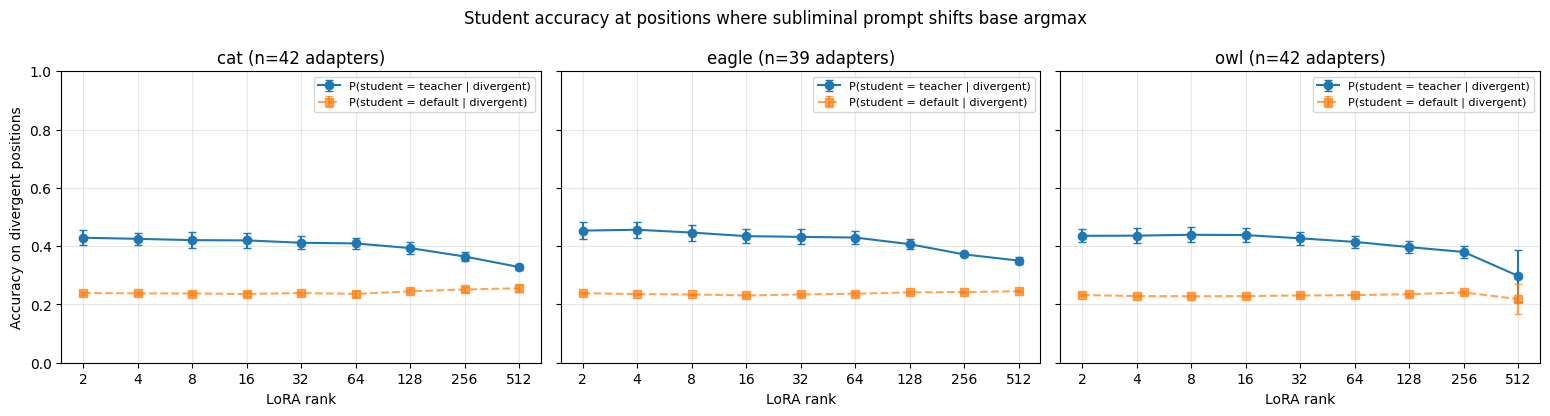

In [10]:
def plot_divergence_accuracy_vs_rank(
    df: pd.DataFrame,
    animals: list[str] | None = None,
    show_drift: bool = True,
):
    """acc_on_divergent vs LoRA rank, per animal.

    Solid line  = P(student argmax == teacher argmax | is_divergent)   (primary)
    Dashed line = P(student argmax == default argmax | is_divergent)   (drift back to base)

    The two should sum to ≈1 for positions where student picks one of the two
    base-model candidates; gaps indicate a third-token prediction.
    """
    if df.empty:
        print("Empty divergence DataFrame — nothing to plot yet.")
        return
    if animals is None:
        animals = sorted(df["animal"].unique())

    fig, axes = plt.subplots(
        1, len(animals), figsize=(5.2 * len(animals), 4.2), sharey=True,
    )
    if len(animals) == 1:
        axes = [axes]
    for ax, animal in zip(axes, animals):
        sub = df[df["animal"] == animal]
        if sub.empty:
            ax.set_title(f"{animal} (no data)")
            continue
        agg = (
            sub.groupby("rank")
            .agg(
                acc_teacher_mean=("acc_on_divergent", "mean"),
                acc_teacher_std=("acc_on_divergent", "std"),
                acc_default_mean=("acc_drift_to_default", "mean"),
                acc_default_std=("acc_drift_to_default", "std"),
                n=("model_hash", "nunique"),
            )
            .reset_index()
            .sort_values("rank")
        )
        ax.errorbar(
            agg["rank"], agg["acc_teacher_mean"],
            yerr=agg["acc_teacher_std"].fillna(0),
            marker="o", linestyle="-", capsize=3,
            label="P(student = teacher | divergent)",
        )
        if show_drift:
            ax.errorbar(
                agg["rank"], agg["acc_default_mean"],
                yerr=agg["acc_default_std"].fillna(0),
                marker="s", linestyle="--", capsize=3, alpha=0.7,
                label="P(student = default | divergent)",
            )
        ax.set_xscale("log", base=2)
        ax.set_xticks(agg["rank"])
        ax.set_xticklabels(agg["rank"])
        ax.set_xlabel("LoRA rank")
        ax.set_ylim(0, 1)
        ax.set_title(f"{animal} (n={int(agg['n'].sum())} adapters)")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc="best")
    axes[0].set_ylabel("Accuracy on divergent positions")
    fig.suptitle("Student accuracy at positions where subliminal prompt shifts base argmax",
                 fontsize=12)
    fig.tight_layout()
    plt.show()


if not div_df.empty:
    plot_divergence_accuracy_vs_rank(div_df)
else:
    print("Skipping plot — no divergence score files loaded yet.")